# Customer Lifetime Value-CLV using Machine Learning

## Project Overview

Customer churn prediction is one of the most important business applications of Machine Learning. It helps organizations identify customers who are likely to discontinue their services, allowing them to take proactive retention measures.

In this project, we will:

- Load and explore the IBM Telco Customer Churn dataset
- Perform data cleaning and preprocessing
- Visualize customer behavior through Exploratory Data Analysis (EDA)
- Build multiple Machine Learning models
- Evaluate and compare model performance
- Save the best-performing model
- Deploy the model using Streamlit

### Machine Learning Models

- Logistic Regression
- Decision Tree
- Random Forest

### Dataset

IBM Telco Customer Churn Dataset

In [3]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

import joblib
import warnings
warnings.filterwarnings("ignore")

## Load the Dataset

The dataset is loaded into a pandas DataFrame for further analysis and preprocessing.

In [4]:
# Load Dataset

df = pd.read_csv("../dataset/customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Dataset Information

In this section, we examine the structure of the dataset, including the number of rows and columns, data types, and missing values.

In [5]:
# Dataset Shape

print("Rows and Columns:", df.shape)

# Dataset Information
print("\nDataset Information:\n")
df.info()

# Missing Values
print("\nMissing Values:\n")
print(df.isnull().sum())

Rows and Columns: (7043, 21)

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  P

## Data Cleaning

Before building machine learning models, the dataset is checked for duplicate records, incorrect data types, and hidden missing values. The `TotalCharges` column is converted to a numeric format after handling blank entries.

In [6]:
# Check for duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [7]:
# Check data type of TotalCharges

print(df["TotalCharges"].dtype)

str


In [8]:
# Check blank values in TotalCharges

print("Blank Values:", (df["TotalCharges"] == " ").sum())

Blank Values: 11


In [10]:
# Replace blank spaces with NaN
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

# Convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values with median
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# Check results
print("Data Type:", df["TotalCharges"].dtype)
print("Missing Values:", df["TotalCharges"].isnull().sum())

Data Type: float64
Missing Values: 0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps in understanding the distribution of variables, identifying trends, and discovering relationships between customer attributes and churn. The visualizations below provide valuable business insights before building machine learning models.

## Churn Distribution

This chart shows the number of customers who stayed versus those who left the company.


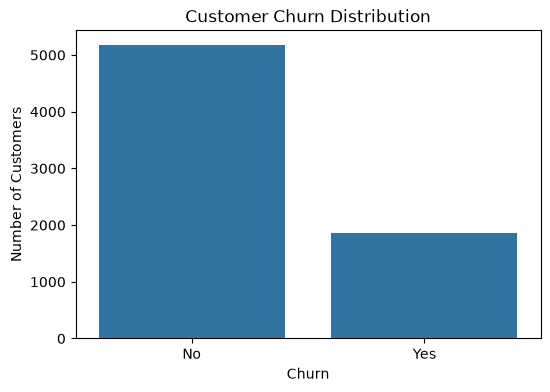

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("../images/churn_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- Most customers did not churn, while a smaller percentage of customers left the company.
- This indicates that the dataset is imbalanced, which should be considered during model evaluation.

## Gender Distribution

This visualization shows the distribution of male and female customers.

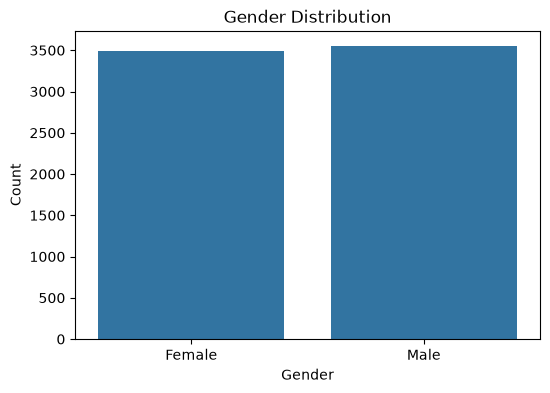

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("../images/gender_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- The number of male and female customers is almost equal.
- This suggests that gender alone may not significantly influence customer churn.

## Contract Type Distribution

This graph illustrates the number of customers under each contract type.

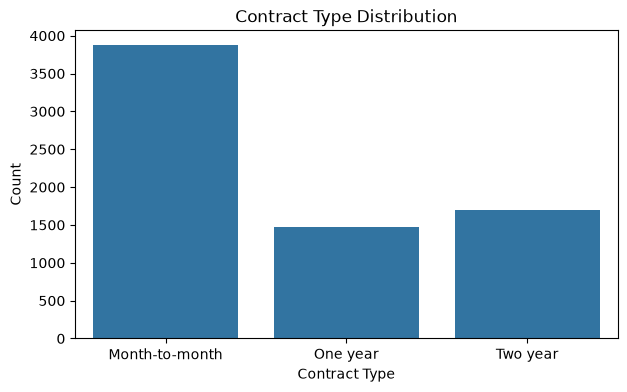

In [13]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', data=df)

plt.title("Contract Type Distribution")
plt.xlabel("Contract Type")
plt.ylabel("Count")

plt.savefig("../images/contract_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- Most customers are subscribed to month-to-month contracts.
- Long-term contracts are less common and may contribute to better customer retention.

## Internet Service Distribution

This chart shows the distribution of customers based on the type of internet service they use.

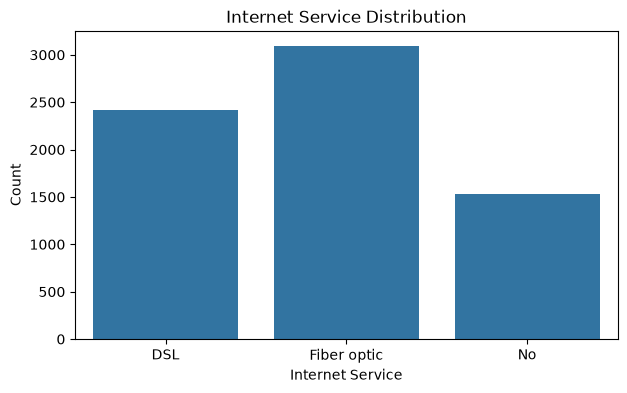

In [14]:
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', data=df)

plt.title("Internet Service Distribution")
plt.xlabel("Internet Service")
plt.ylabel("Count")

plt.savefig("../images/internet_service_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- Fiber optic and DSL are the most commonly used internet services.
- A smaller group of customers does not use internet services.

## Monthly Charges Distribution

The histogram illustrates how monthly charges are distributed among customers.

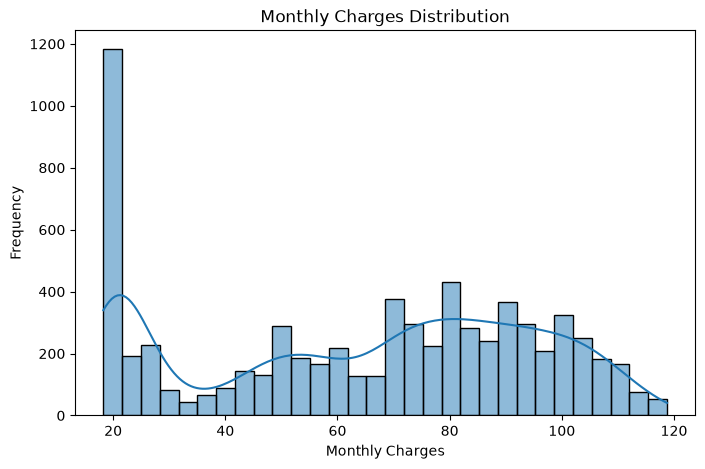

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.savefig("../images/monthly_charges_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- Monthly charges vary across customers, with many customers paying moderate monthly fees.
- The distribution helps identify different pricing groups among customers.

## Customer Tenure Distribution

This graph shows how long customers have stayed with the company.

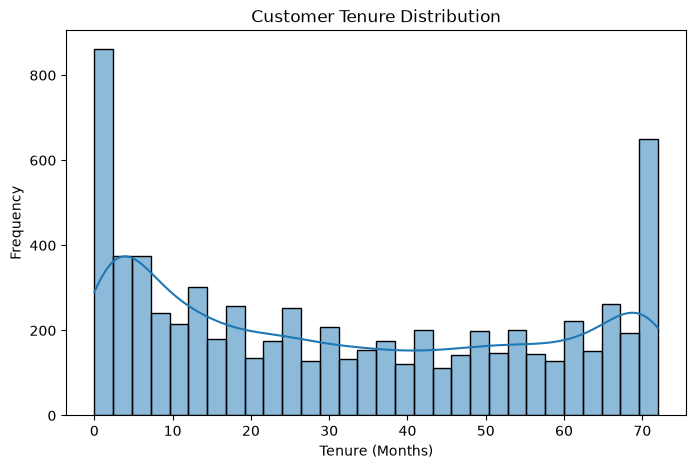

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['tenure'], bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.savefig("../images/tenure_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- The dataset contains both new and long-term customers.
- Many customers have relatively short tenures, while a considerable number have remained with the company for several years.

## Monthly Charges by Churn Status

This box plot compares monthly charges for customers who churned and those who stayed.

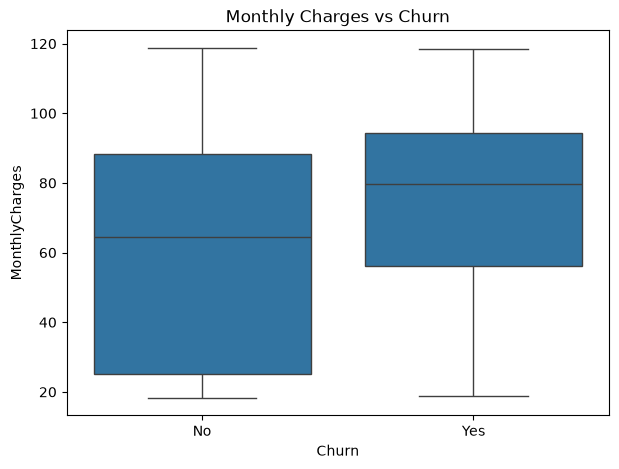

In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title("Monthly Charges vs Churn")

plt.savefig("../images/monthly_charges_vs_churn.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- Customers who churn tend to have higher monthly charges than those who stay.
- This suggests that pricing may influence customer retention.

## Churn by Contract Type

This chart compares customer churn across different contract types.

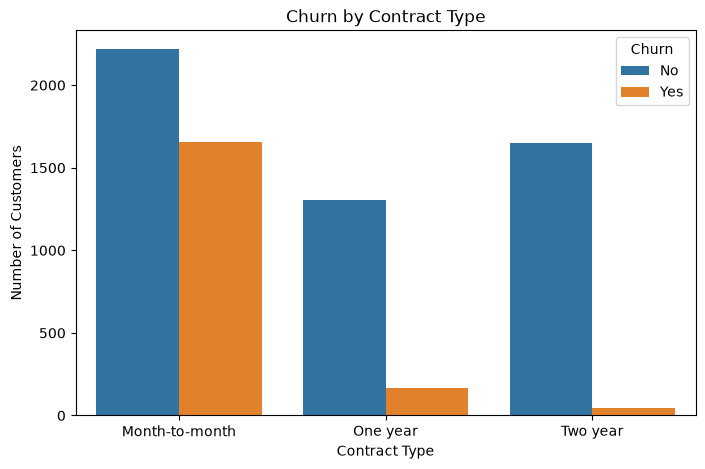

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.savefig("../images/churn_by_contract.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- Customers with month-to-month contracts show the highest churn rate.
- Customers with one-year and two-year contracts are more likely to remain with the company.

## Churn by Senior Citizen Status

This visualization compares churn behavior between senior citizens and non-senior citizens.

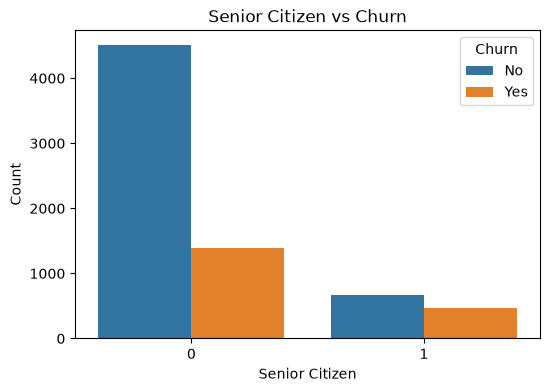

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df)

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Count")

plt.savefig("../images/seniorcitizen_churn.png", dpi=300, bbox_inches='tight')

plt.show()

### Interpretation

- Senior citizens appear to have a higher proportion of churn compared to non-senior customers.
- This indicates that age group may influence customer retention.

## Correlation Heatmap

The heatmap shows relationships between numerical and encoded categorical features.

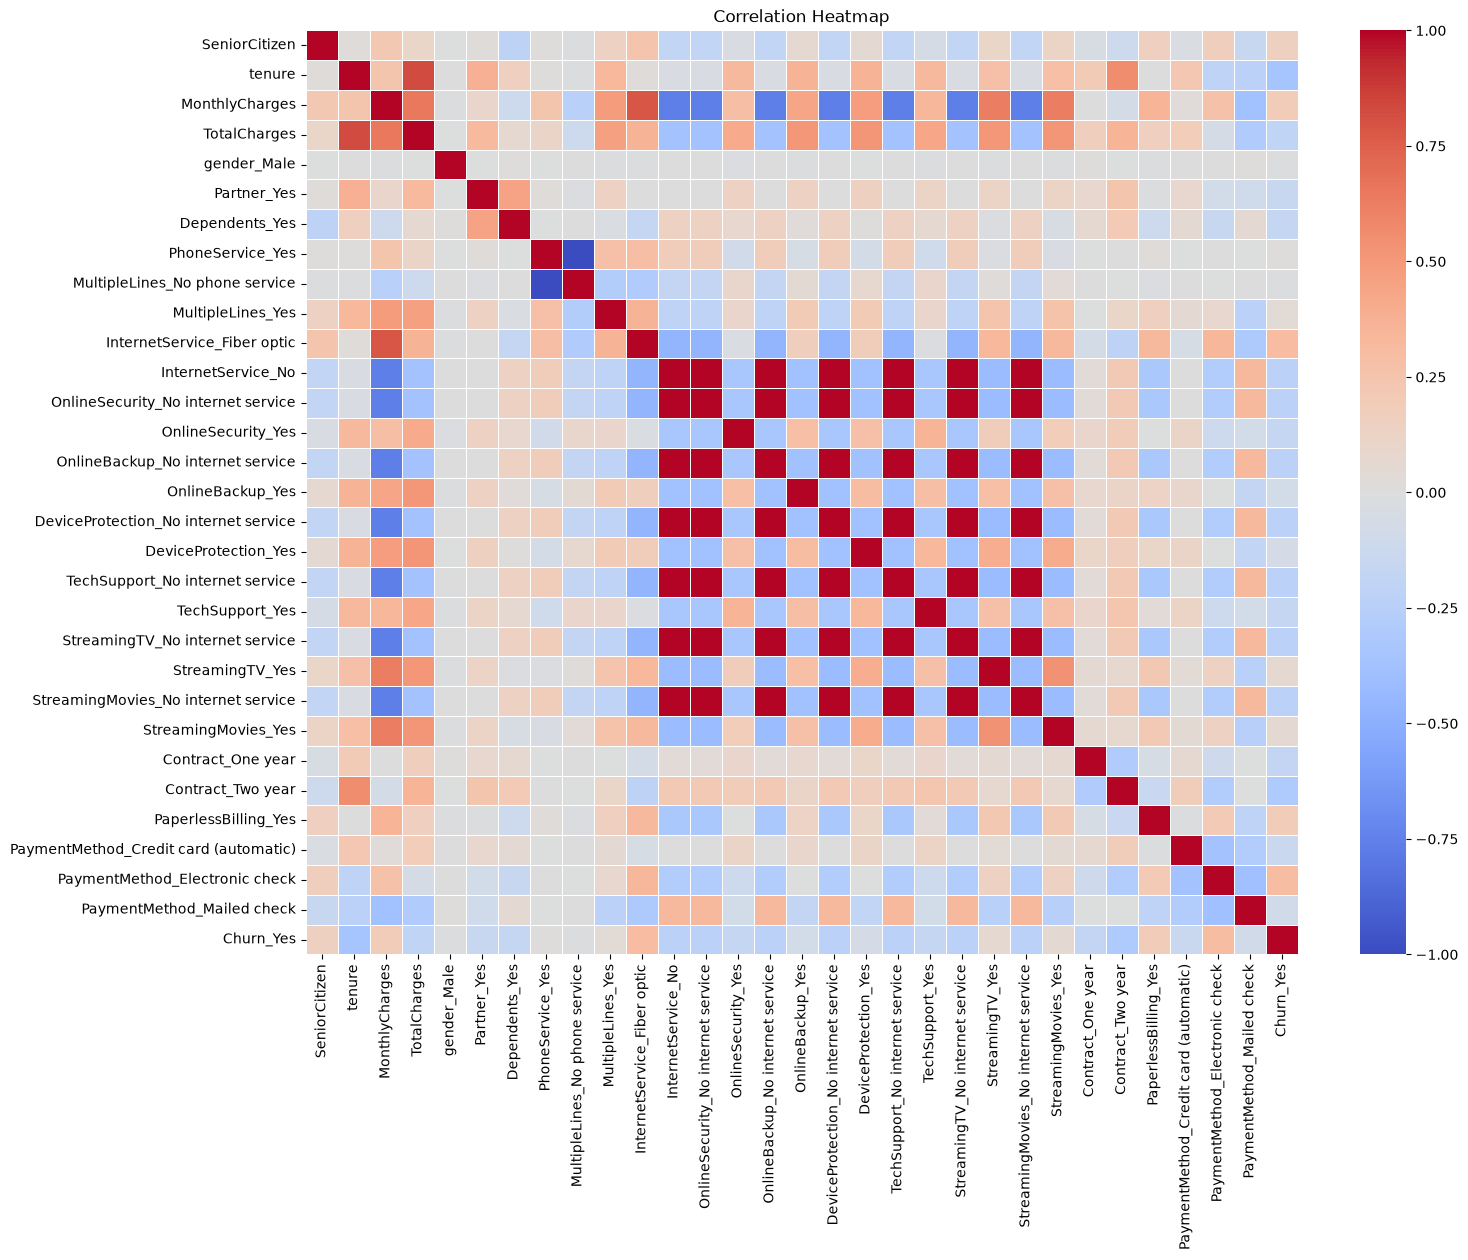

In [24]:
# Create a copy
heatmap_df = df.copy()

# Drop customerID
heatmap_df = heatmap_df.drop(columns=["customerID"])

# Convert categorical columns to numeric
heatmap_df = pd.get_dummies(heatmap_df, drop_first=True)

# Correlation matrix
corr = heatmap_df.corr()

# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

- The correlation heatmap highlights the relationship between different customer attributes.
- Features such as contract type, tenure, and monthly charges show a stronger relationship with customer churn.
- Highly correlated features may have a greater influence on predicting whether a customer will leave the service.

# Machine Learning

Before training the models, categorical variables are converted into numerical format, and the dataset is divided into features and the target variable.

In [25]:
# Create a copy of the dataset
model_df = df.copy()

# Drop customerID
model_df = model_df.drop("customerID", axis=1)

# Convert categorical variables into numerical variables
model_df = pd.get_dummies(model_df, drop_first=True)

# Features and Target
X = model_df.drop("Churn_Yes", axis=1)
y = model_df["Churn_Yes"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7043, 30)
Target Shape: (7043,)


## Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the machine learning models, while the testing data is used to evaluate their performance on unseen data.

In [26]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 30)
Testing Data: (1409, 30)


## Logistic Regression

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems. It predicts whether a customer is likely to churn based on the input features.

In [28]:
# Logistic Regression Model

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8211497515968772

Classification Report:

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



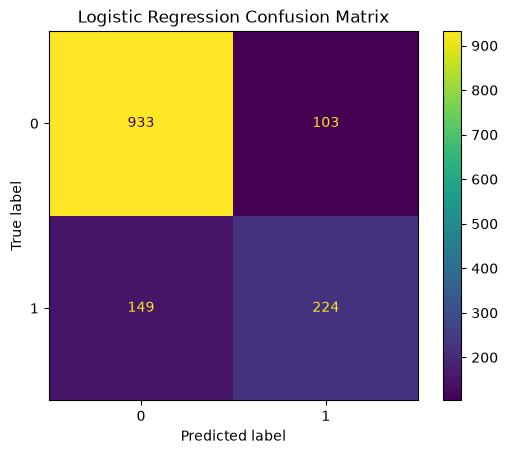

In [29]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")

plt.savefig("../images/logistic_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Decision Tree Classifier

Decision Tree is a supervised learning algorithm that classifies customers by learning decision rules from the training data.

In [30]:
# Decision Tree Model

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7097232079489

Classification Report:

              precision    recall  f1-score   support

       False       0.80      0.80      0.80      1036
        True       0.45      0.45      0.45       373

    accuracy                           0.71      1409
   macro avg       0.63      0.63      0.63      1409
weighted avg       0.71      0.71      0.71      1409



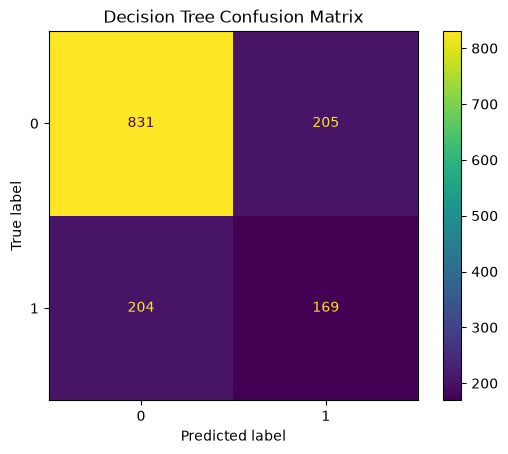

In [31]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Decision Tree Confusion Matrix")

plt.savefig("../images/decision_tree_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [32]:
# Random Forest Model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7892122072391767

Classification Report:

              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1036
        True       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



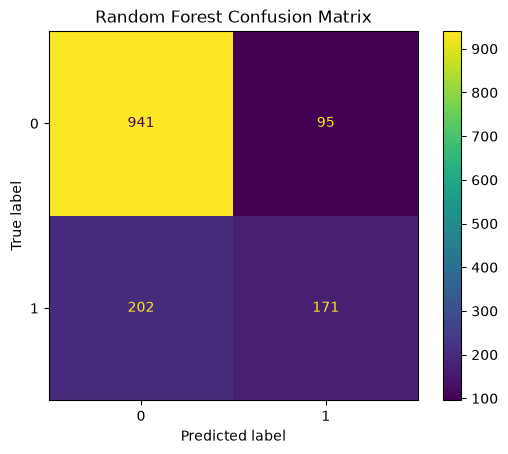

In [33]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.savefig("../images/random_forest_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Model Comparison

The performance of all machine learning models is compared using their accuracy scores to identify the best-performing model for customer churn prediction.

In [35]:
# Compare Model Performance

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison = comparison.sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
0,Logistic Regression,0.821150
2,Random Forest,0.789212
1,Decision Tree,0.709723


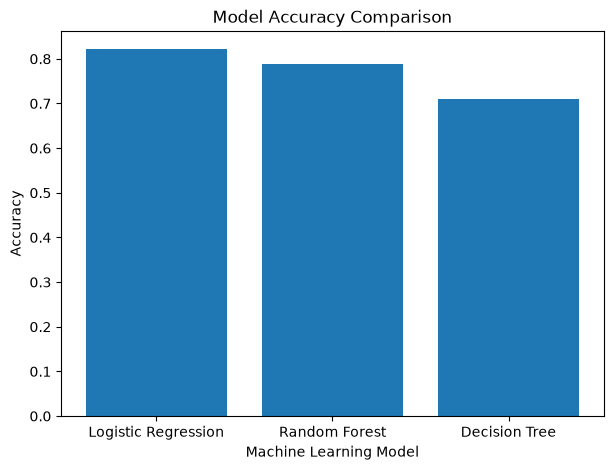

In [36]:
plt.figure(figsize=(7,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.savefig("../images/model_comparison.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Feature Importance

Feature importance identifies which customer attributes contribute the most to predicting customer churn.

In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.189701
1,tenure,0.175710
2,MonthlyCharges,0.172418
10,InternetService_Fiber optic,0.036053
28,PaymentMethod_Electronic check,0.035302
25,Contract_Two year,0.030435
13,OnlineSecurity_Yes,0.029238
4,gender_Male,0.027423
26,PaperlessBilling_Yes,0.025295
5,Partner_Yes,0.024209


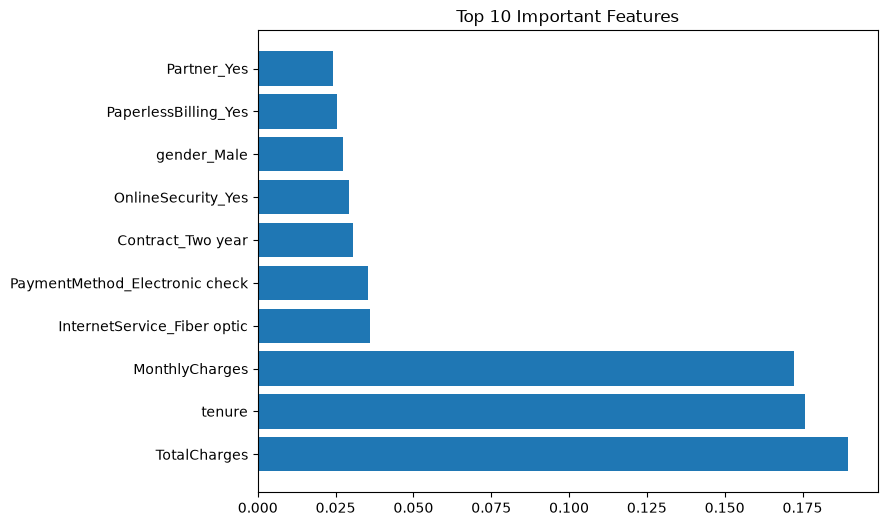

In [38]:
top10 = importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")

plt.savefig("../images/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Saving the Best Model

The Random Forest model achieved the highest performance and is saved for future predictions and deployment.

In [39]:
joblib.dump(rf, "../models/random_forest_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


# Conclusion

Three machine learning algorithms were trained and evaluated for customer churn prediction.

Among the models, Random Forest achieved the best overall performance and was selected as the final model. The project demonstrates how machine learning can help businesses identify customers who are likely to leave and support data-driven customer retention strategies.